In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Gurugram.csv")

In [3]:
data.head()

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Socity,Company Name,Flat Type
0,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000.0,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3.0,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000.0,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4.0,Outside Socity,Outside,Plot
4,24000000.0,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3.0,Anant Raj Estate Plots,Anant,Floor


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          19515 non-null  str    
 1   Status         19515 non-null  str    
 2   Area           19515 non-null  int64  
 3   Rate per sqft  19515 non-null  str    
 4   Property Type  19515 non-null  str    
 5   Locality       19515 non-null  str    
 6   Builder Name   19515 non-null  str    
 7   RERA Approval  19515 non-null  str    
 8   BHK_Count      19515 non-null  float64
 9   Socity         19515 non-null  str    
 10  Company Name   19515 non-null  str    
 11  Flat Type      19515 non-null  str    
dtypes: float64(1), int64(1), str(10)
memory usage: 1.8 MB


In [5]:
data.describe()

,Area,BHK_Count
count,19515.000000,19515.000000
mean,2545.455752,3.229772
std,9550.629288,4.923873
min,60.000000,0.000000
25%,1423.000000,3.000000
50%,2000.000000,3.000000
75%,2800.000000,4.000000
max,958320.000000,132.000000


In [6]:
data.rename(columns = {'Socity':"Society"},inplace= True)

In [8]:
data.dtypes

Price                str
Status               str
Area               int64
Rate per sqft        str
Property Type        str
Locality             str
Builder Name         str
RERA Approval        str
BHK_Count        float64
Society              str
Company Name         str
Flat Type            str
dtype: object

In [9]:
data.columns.tolist()

['Price',
 'Status',
 'Area',
 'Rate per sqft',
 'Property Type',
 'Locality',
 'Builder Name',
 'RERA Approval',
 'BHK_Count',
 'Society',
 'Company Name',
 'Flat Type']

# Convert Data Types

In [17]:
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")

In [21]:
data["price"] = data["price"].astype(str).str.replace(",", "").astype(float)
data["area"] = data["area"].astype(str).str.replace(",", "").astype(int)
data["rate_per_sqft"] = data["rate_per_sqft"].astype(str).str.replace(",", "").astype(int)

In [22]:
data = data.drop_duplicates()

# Question 1: Which is the costliest flat ?

In [28]:
Costliest_flat = data.groupby('flat_type')['price'].sum().reset_index().sort_values('price' ,ascending = False)

In [29]:
Costliest_flat

,flat_type,price
0,Apartment,4.545855e+11
4,Plot,5.784803e+10
1,Floor,2.668101e+10
5,Villa,1.912510e+10
2,House,5.611700e+09
3,Penthouse,4.411100e+09


In [30]:
costly_flat = data['price'].max()

In [31]:
costly_flat

np.float64(1226300000.0)

In [34]:
costliest_flat= data.loc[[data['price'].idxmax()]]
costliest_flat

,price,status,area,rate_per_sqft,property_type,locality,builder_name,rera_approval,bhk_count,society,company_name,flat_type
2839,1.226300e+09,Ready to move,16500,74323,6 BHK Apartment in DLF Camellias,Sector 42,Provident Capital,Not approved by RERA,6.0,DLF Camellias,DLF,Apartment


# Question 2: Which locality has the highest average price?

In [36]:
highest_avg_price= data.groupby('locality')['price'].mean().sort_values(ascending= False)
highest_avg_price

locality
Baliawas                5.833333e+08
Sector 42               5.023612e+08
Beverly Park            1.953667e+08
Aralias Drive           1.636583e+08
Golf Course Road        1.475139e+08
                            ...     
Sohna Rewari Road       6.200000e+05
SULTANPUR BIRD CENTU    6.000000e+05
Sultanpur               4.875000e+05
Sector 1 Sohna          2.600000e+05
Sector-59 Gurgaon       1.700000e+05
Name: price, Length: 245, dtype: float64

# Which locality has the highest rate per square foot?

In [40]:
data.groupby("locality")["rate_per_sqft"].mean().sort_values(ascending=False)

locality
Sector 42                 55989.083333
Sector 113                52404.145374
Sector 114                33347.200000
Sector 53                 29202.789474
Sector 54                 28109.250871
                              ...     
Sohna Palwal Road           688.000000
Sohna Rewari Road           688.000000
Sector 1 Sohna              577.000000
Sector-59 Gurgaon           188.000000
37D Dwarka Exp Gurgaon      125.000000
Name: rate_per_sqft, Length: 245, dtype: float64

In [39]:
data.loc[data["rate_per_sqft"].idxmax(), "locality"]

'Sector 46'

In [41]:
data["rate_per_sqft"].max()

np.int64(310000)

In [42]:
data.loc[data["rate_per_sqft"].idxmax(), "locality"] #“Jis row mein rate_per_sqft sabse zyada hai, us row ki locality batao.”

'Sector 46'

In [43]:
data.loc[data["rate_per_sqft"].idxmax(), ["locality", "rate_per_sqft"]]

locality         Sector 46
rate_per_sqft       310000
Name: 2115, dtype: object

# Do ready-to-move properties cost more than under-construction properties?

In [44]:
ready_to_move_cost = data[data['status'] == 'Ready to move']['price'].mean()
under_const_cost = data[data['status'] == 'Under Construction']['price'].mean()

In [46]:
if ready_to_move_cost > under_const_cost:
    print("Ready to move costs higher than Under construction properties")
else :
    print("Under constructio costs higher")

Ready to move costs higher than Under construction properties


In [47]:
data.groupby("status")["price"].median()


status
New                   13450000.0
Ready to move         26000000.0
Resale                36500000.0
Under Construction    28600000.0
Name: price, dtype: float64

# Do RERA-approved properties command a price premium?

In [50]:
Rera_approved_price = data[data['rera_approval'] == 'Approved by RERA']['price'].mean()

In [51]:
Rera_approved_price

np.float64(38607015.599192515)

In [52]:
NoRera_approved_price = data[data['rera_approval'] == 'Not approved by RERA']['price'].mean()

In [53]:
NoRera_approved_price

np.float64(40790151.81217233)

In [54]:
data.groupby("rera_approval")["price"].median() #median gives a better idea of the typical property price.

rera_approval
Approved by RERA        27100000.0
Not approved by RERA    25800000.0
Name: price, dtype: float64

In [55]:
#“Yes, RERA-approved properties appear to command a price premium. The median price of RERA-approved properties is ₹2.71 crore, compared with ₹2.58 crore for non-approved properties, indicating approximately a 5.04% premium.”

# How does area (sqft) impact property price?

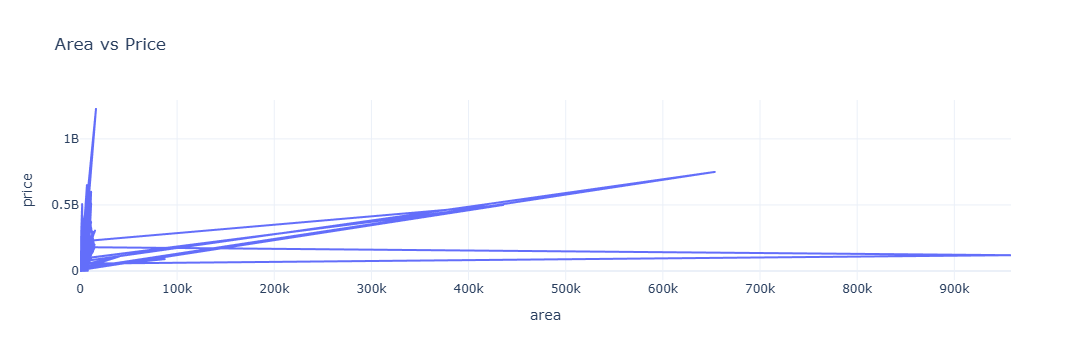

In [57]:
import plotly.express as px
import plotly.graph_objects as go #graphs
import plotly.io as pio #templates
import plotly.colors as colors #colors
pio.templates.default = 'plotly_white'


fig = px.line(data,
              x='area',
              y='price',
              title="Area vs Price")
fig.show()

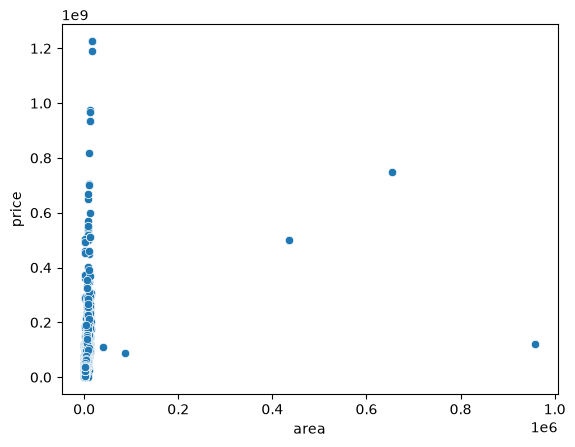

In [58]:
sns.scatterplot(x="area", y="price", data=data)
plt.show()

# Which BHK configuration is the most expensive on average?

In [61]:
Expensive_BHK = data.groupby('bhk_count')['price'].mean().sort_values(ascending=False)

In [62]:
Expensive_BHK.head(2)

bhk_count
7.0    2.193125e+08
6.0    1.691315e+08
Name: price, dtype: float64

In [63]:
data.groupby("bhk_count")["price"].mean().idxmax()

np.float64(7.0)

# Question 8: Which property type is the costliest?

In [66]:
 data.loc[data["price"].idxmax(), "property_type"]

'6 BHK Apartment in DLF Camellias'

# Question 9: Do certain builders price higher?

In [69]:
data.groupby('builder_name')['price'].sum().sort_values(ascending= False).head(10)

builder_name
Proptiger                         4.070301e+10
properties for sale in Gurgaon    3.283650e+10
home                              3.272441e+10
Property In Gurgaon               3.239334e+10
Sharma Prop                       3.038492e+10
Provident Capital                 1.709622e+10
WADHWA REALTORS                   1.706705e+10
The Assetree                      1.578036e+10
Search My Property                1.130670e+10
Multi Home Realtors               9.064900e+09
Name: price, dtype: float64

In [71]:
data.groupby("company_name")["rate_per_sqft"].mean().sort_values(ascending=False)

company_name
Camelliaass    44724.333333
Cameliaas      40000.000000
Tulip          28571.121495
Prom           27358.600000
Magnoliaass    26666.000000
                   ...     
U               1376.750000
Baliawas        1147.000000
OM              1066.583333
SOHNA            722.000000
SR               438.500000
Name: rate_per_sqft, Length: 269, dtype: float64

 # Question 10: Are larger homes more expensive per sqft?

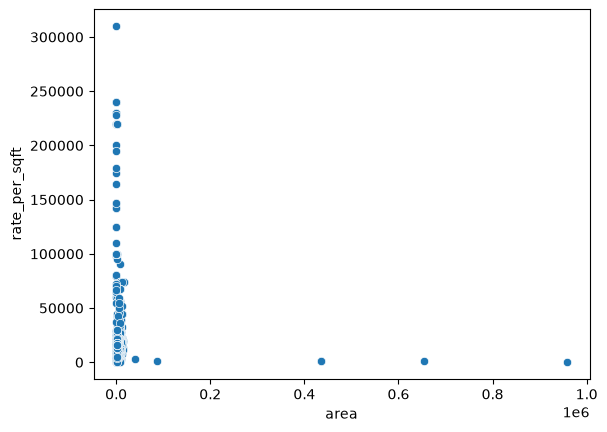

In [72]:
sns.scatterplot(x="area", y="rate_per_sqft", data=data)
plt.show()

In [73]:
#answer would be no 